In [3]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor

# 1. Load the dataset
file_path = '../output/training_data_v6_no0min_trial.csv'
df = pd.read_csv(file_path)

def generate_fpl_windows(df, window_size=6):
    train_data = []
    
    # Mapping to your exact column names from debug output
    uuid_col = 'Player UUID'
    season_col = 'season'
    gw_col = 'Gameweek'
    points_col = 'Total Points'
    pos_col = 'Position'

    # Sort to ensure chronological order per player
    df = df.sort_values([uuid_col, season_col, gw_col])
    
    # Group by UUID so windows stay within a single player's history
    for pid, group in df.groupby(uuid_col):
        points = group[points_col].values
        
        # Check if the player has enough data points
        if len(points) <= window_size:
            continue
            
        # Get the position (it's the same for all rows of this player)
        position = group[pos_col].iloc[0] 
        
        for i in range(len(points) - window_size):
            window = points[i : i + window_size]
            target = points[i + window_size]
            
            # Rule: Skip windows where the player scored 0 points for 6 weeks straight
            if np.all(window == 0):
                continue
                
            # Create a row: [lag_6, lag_5, lag_4, lag_3, lag_2, lag_1, position, target]
            row = list(window) + [position, target]
            train_data.append(row)
            
    # Define columns: lag_6 is oldest, lag_1 is most recent
    columns = [f'lag_{i}' for i in range(window_size, 0, -1)] + ['position', 'target']
    return pd.DataFrame(train_data, columns=columns)

# Execute the transformation
windowed_df = generate_fpl_windows(df)

# Convert position to 'category' for LightGBM
windowed_df['position'] = windowed_df['position'].astype('category')

# Final check
print(f"Dataset created with {windowed_df.shape[0]} rows and {windowed_df.shape[1]} columns.")
windowed_df.head()

Dataset created with 20580 rows and 8 columns.


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position,target
0,1,1,2,2,0,1,MID,1
1,1,2,2,0,1,1,MID,2
2,2,2,0,1,1,2,MID,2
3,2,0,1,1,2,2,MID,2
4,0,1,1,2,2,2,MID,1


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Prepare X (features) and y (target)
# We drop 'target' for X, and keep 'position' as it is already a category
X = windowed_df.drop(columns=['target'])
y = windowed_df['target']

# 2. Chronological Split
# Since your goal is to predict 2026, we'll use the last 15% of the 
# generated windows as our validation set to mimic "recent" performance.
split_index = int(len(windowed_df) * 0.85)

X_train_raw = X.iloc[:split_index]
X_val_raw = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_val = y.iloc[split_index:]

# 3. Scaling the numeric 'lag' features
# We don't scale 'position', so we separate it briefly
lag_cols = [c for c in X.columns if 'lag' in c]

scaler = StandardScaler()

# Fit and transform training lags
X_train_scaled = X_train_raw.copy()
X_train_scaled[lag_cols] = scaler.fit_transform(X_train_raw[lag_cols])

# Transform validation lags using the SAME scaler
X_val_scaled = X_val_raw.copy()
X_val_scaled[lag_cols] = scaler.transform(X_val_raw[lag_cols])

print(f"Training set size: {len(X_train_scaled)}")
print(f"Validation set size: {len(X_val_scaled)}")
print("\nFirst few rows of scaled training data:")
X_train_scaled.head()

Training set size: 17493
Validation set size: 3087

First few rows of scaled training data:


,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1,position
0,-0.614551,-0.614249,-0.284432,-0.285614,-0.943225,-0.614697,MID
1,-0.614551,-0.285765,-0.284432,-0.943706,-0.614288,-0.614697,MID
2,-0.285089,-0.285765,-0.943970,-0.614660,-0.614288,-0.285943,MID
3,-0.285089,-0.942734,-0.614201,-0.614660,-0.285350,-0.285943,MID
4,-0.944013,-0.614249,-0.614201,-0.285614,-0.285350,-0.285943,MID


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[198]	valid_0's l2: 8.21656

--- Model Performance ---
Mean Absolute Error: 2.1026
Root Mean Squared Error: 2.8665


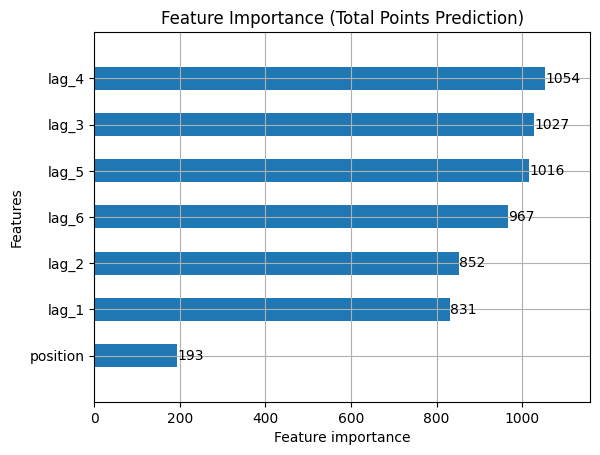

In [5]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Initialize the LightGBM Regressor
# We use moderate hyperparameters; 'verbosity': -1 keeps the output clean
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    num_leaves=31,
    boosting_type='gbdt',
    random_state=42,
    verbosity=-1
)

# 2. Fit the model
# We pass the validation set to monitor performance
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 3. Evaluation
preds = model.predict(X_val_scaled)
mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))

print(f"\n--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

# 4. Feature Importance Plot
lgb.plot_importance(model, height=0.5, title="Feature Importance (Total Points Prediction)")
plt.show()